In [1]:
import sys

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
import joblib
import os
import math

from abc import ABC, abstractmethod

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer


import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, AutoModelForMaskedLM


# Go one level up from notebooks/ to reach root
sys.path.append(os.path.abspath('..'))

# Now import freely
from src.hyenadna_model import HyenaDNAModel
from src.sklearn_model import SklearnModel
from src.universal_model import UniversalModel
import src.utils as utils

In [2]:
df = pd.read_csv("../data/cleaned_data.csv")
df

,accession,length,gc_content,sequence,label
0,NC_036615.1,2330,40.26,GGCATAAGCAGAGGATTTTATAACAATGGAAATAAACCCATATCTA...,influenza D
1,NC_036616.1,2364,39.89,GGCATAAGCAGAGGATGTCACTACTATTAACGCTCGCAAAAGAGTA...,influenza D
2,NC_036617.1,1775,44.00,GGCATAAGCAGGAGATTATTAAGCAATATGGACTCAACAAAAGCCC...,influenza D
3,NC_036618.1,2049,43.34,AGCATAAGCAGGAGATTTTCAAAGATGTTTTTGCTTCTAGCAACAA...,influenza D
4,NC_036619.1,2195,39.54,GGCATAAGCAGGAGATTTAGAAATGTCTAGTGTAATCAGAGAAATC...,influenza D
...,...,...,...,...,...
10462,AF389122.1,890,44.72,AGCAAAAGCAGGGTGACAAAGACATAATGGATCCAAACACTGTGTC...,H1N1
10463,AF251391.1,988,47.87,TATTGAAAGATGAGCCTTCTAACCGAGGTCGAAACGTATGTTCTCT...,H3N2
10464,AF102656.1,1350,44.30,ATGAATCCAAATCAGAAGATAATAACCATTGGATCAATCTGCATGG...,H5N1
10465,J02150.1,890,44.27,AGCAAAAGCAGGGTGACAAAGACATAATGGATCCAAACACTGTGTC...,H1N1


In [3]:
X = df['sequence']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8373,)
(8373,)
(2094,)
(2094,)


In [4]:
target_names = list(set(y))

In [5]:
label_encoder = joblib.load("../models/hyenadna/label_encoder.pkl")
hyenadna = utils.load_model("../models/hyenadna", num_labels=len(target_names))
target_names = list(label_encoder.classes_)
hdna_report, hdna_f1, hdna_cm, hdna_eval_results = hyenadna.evaluate(X_test, y_test, target_names, label_encoder)

/home/nifdi/miniconda3/envs/tcgabio/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

[transformers] HyenaDNAForSequenceClassification LOAD REPORT from: LongSafari/hyenadna-small-32k-seqlen-hf
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


In [6]:
vectorizer = CountVectorizer(analyzer="char", ngram_range=(3, 3))
kmer_matrix = vectorizer.fit_transform(df["sequence"])
kmer_names = vectorizer.get_feature_names_out()
kmer_df = pd.DataFrame(kmer_matrix.toarray(), columns=kmer_names, index=df.index)
kmer_freq_df = kmer_df.div(df["length"], axis=0)
kmer_freq_df["label"] = df["label"]

X = kmer_freq_df[kmer_freq_df.columns.drop('label')]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(kmer_freq_df['label'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8373, 584)
(8373,)
(2094, 584)
(2094,)


In [7]:
label_encoder   = joblib.load("../models/baseline/label_encoder.pkl")
lr_model        = joblib.load("../models/baseline/logistic_regression.pkl")
random_forest   = joblib.load("../models/baseline/random_forest.pkl")
xgb_classifier  = joblib.load("../models/baseline/xgb_classifier.pkl")

In [8]:
lr_report, lr_f1, lr_cm, lr_eval_results = lr_model.evaluate(X_test, y_test, target_names, label_encoder)
rf_report, rf_f1, rf_cm, rf_eval_results = random_forest.evaluate(X_test, y_test, target_names, label_encoder)
xgb_report, xgb_f1, xgb_cm, xgb_eval_results = xgb_classifier.evaluate(X_test, y_test, target_names, label_encoder)

/home/nifdi/miniconda3/envs/tcgabio/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nifdi/miniconda3/envs/tcgabio/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nifdi/miniconda3/envs/tcgabio/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [9]:
models = {
    "Logistic Regression": lr_eval_results,
    "Random Forest":       rf_eval_results,
    "XGBoost":             xgb_eval_results,
    "HDNA":                hdna_eval_results,
}

In [10]:
rows = []
for name, res in models.items():
    rows.append({
        "Model":                    name,
        "Accuracy":                 res["accuracy"],
        "Macro F1":                 res["macro_f1"],
        "Weighted F1":              res["weighted_f1"],
        "Macro AUC":                res["macro_auc"],
        "Pred Time (ms/sample)":    res["prediction_time_per_sample_ms"],
        "Model Size (MB)":          res["model_size_mb"],
    })

In [11]:
scoreboard = pd.DataFrame(rows).set_index("Model").round(4)
scoreboard

,Accuracy,Macro F1,Weighted F1,Macro AUC,Pred Time (ms/sample),Model Size (MB)
Model,,,,,,
Logistic Regression,0.2359,0.0225,0.0901,0.7015,0.0054,0.0802
Random Forest,0.8801,0.8056,0.8740,0.9778,0.0319,56.6545
XGBoost,0.8749,0.8072,0.8705,0.9868,0.0384,2.9057
HDNA,0.8548,0.7634,0.8529,0.9806,11.5954,15.5724


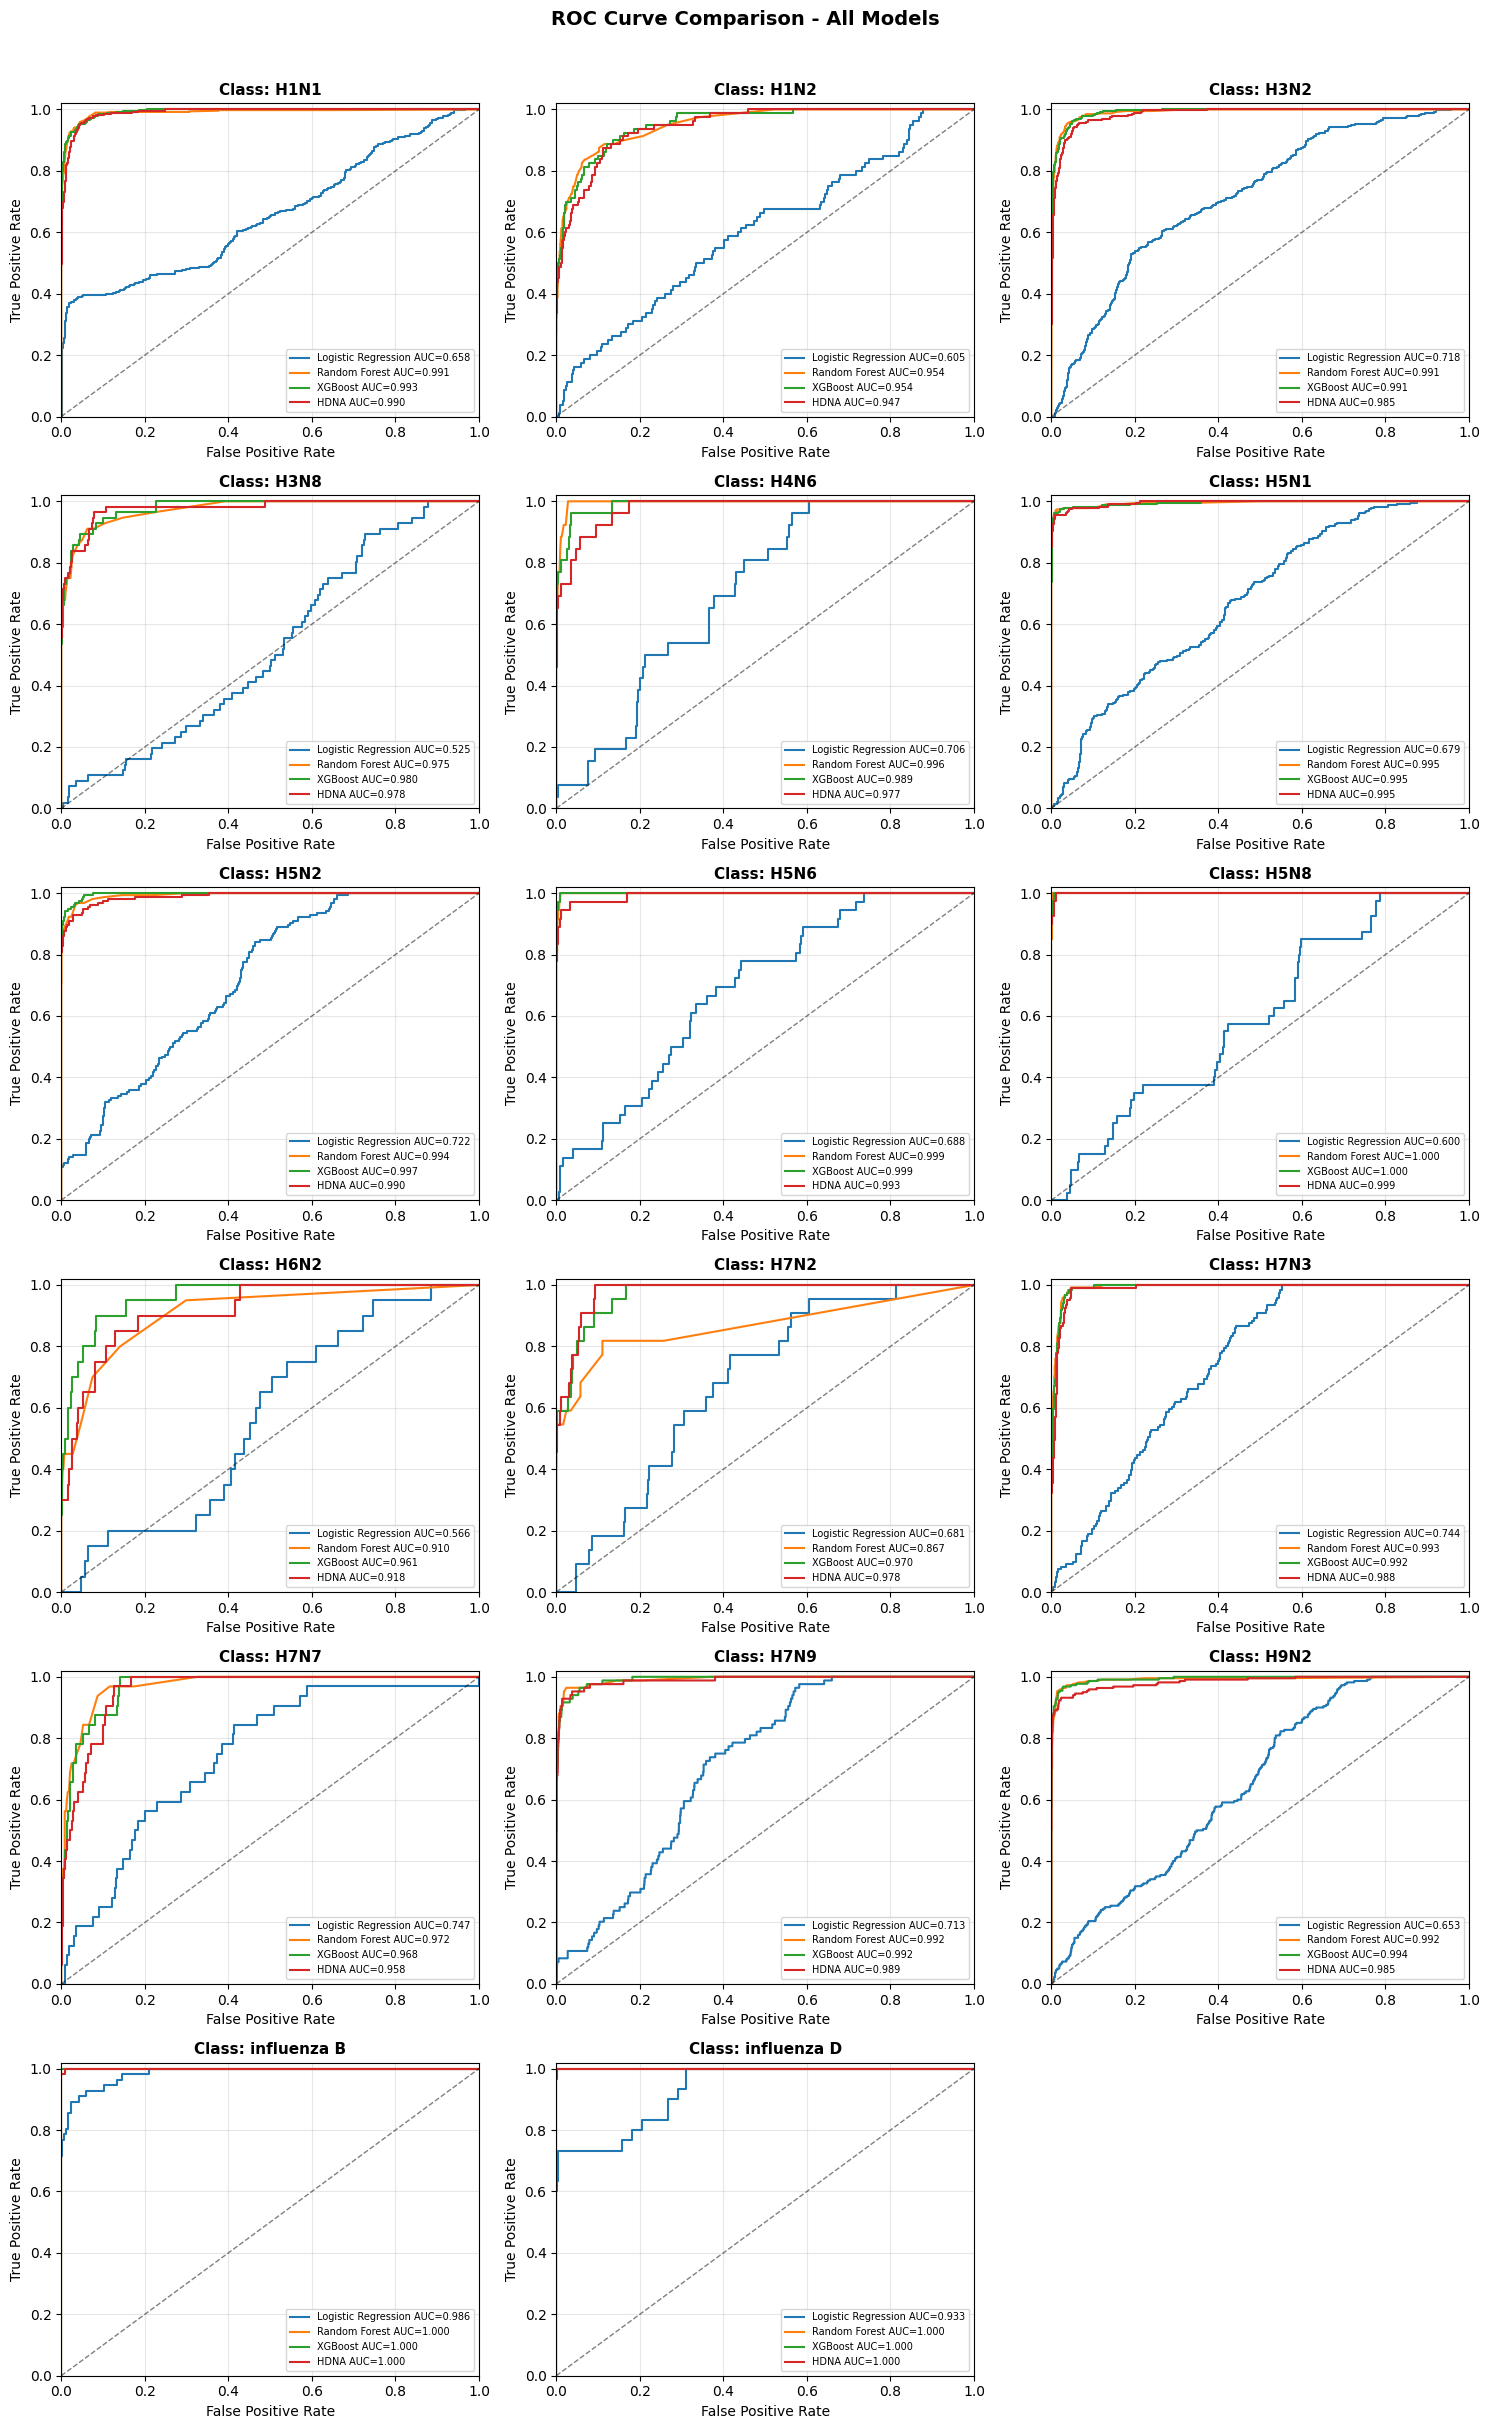

In [12]:
n_cols = 3
n_classes = len(target_names)
n_rows = math.ceil((n_classes+1)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, cls in enumerate(target_names):
    ax = axes[i]
    for (model_name, res) in models.items():
        false_positive_rate, true_positive_rate, _ = res["roc_curves"][cls]
        auc = res["auc_scores"][cls]
        ax.plot(false_positive_rate, true_positive_rate, label=f"{model_name} AUC={auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_title(f"Class: {cls}", fontsize=11, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=7, loc="lower right")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)


axes[n_classes].set_visible(False)

fig.suptitle("ROC Curve Comparison - All Models", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/results_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

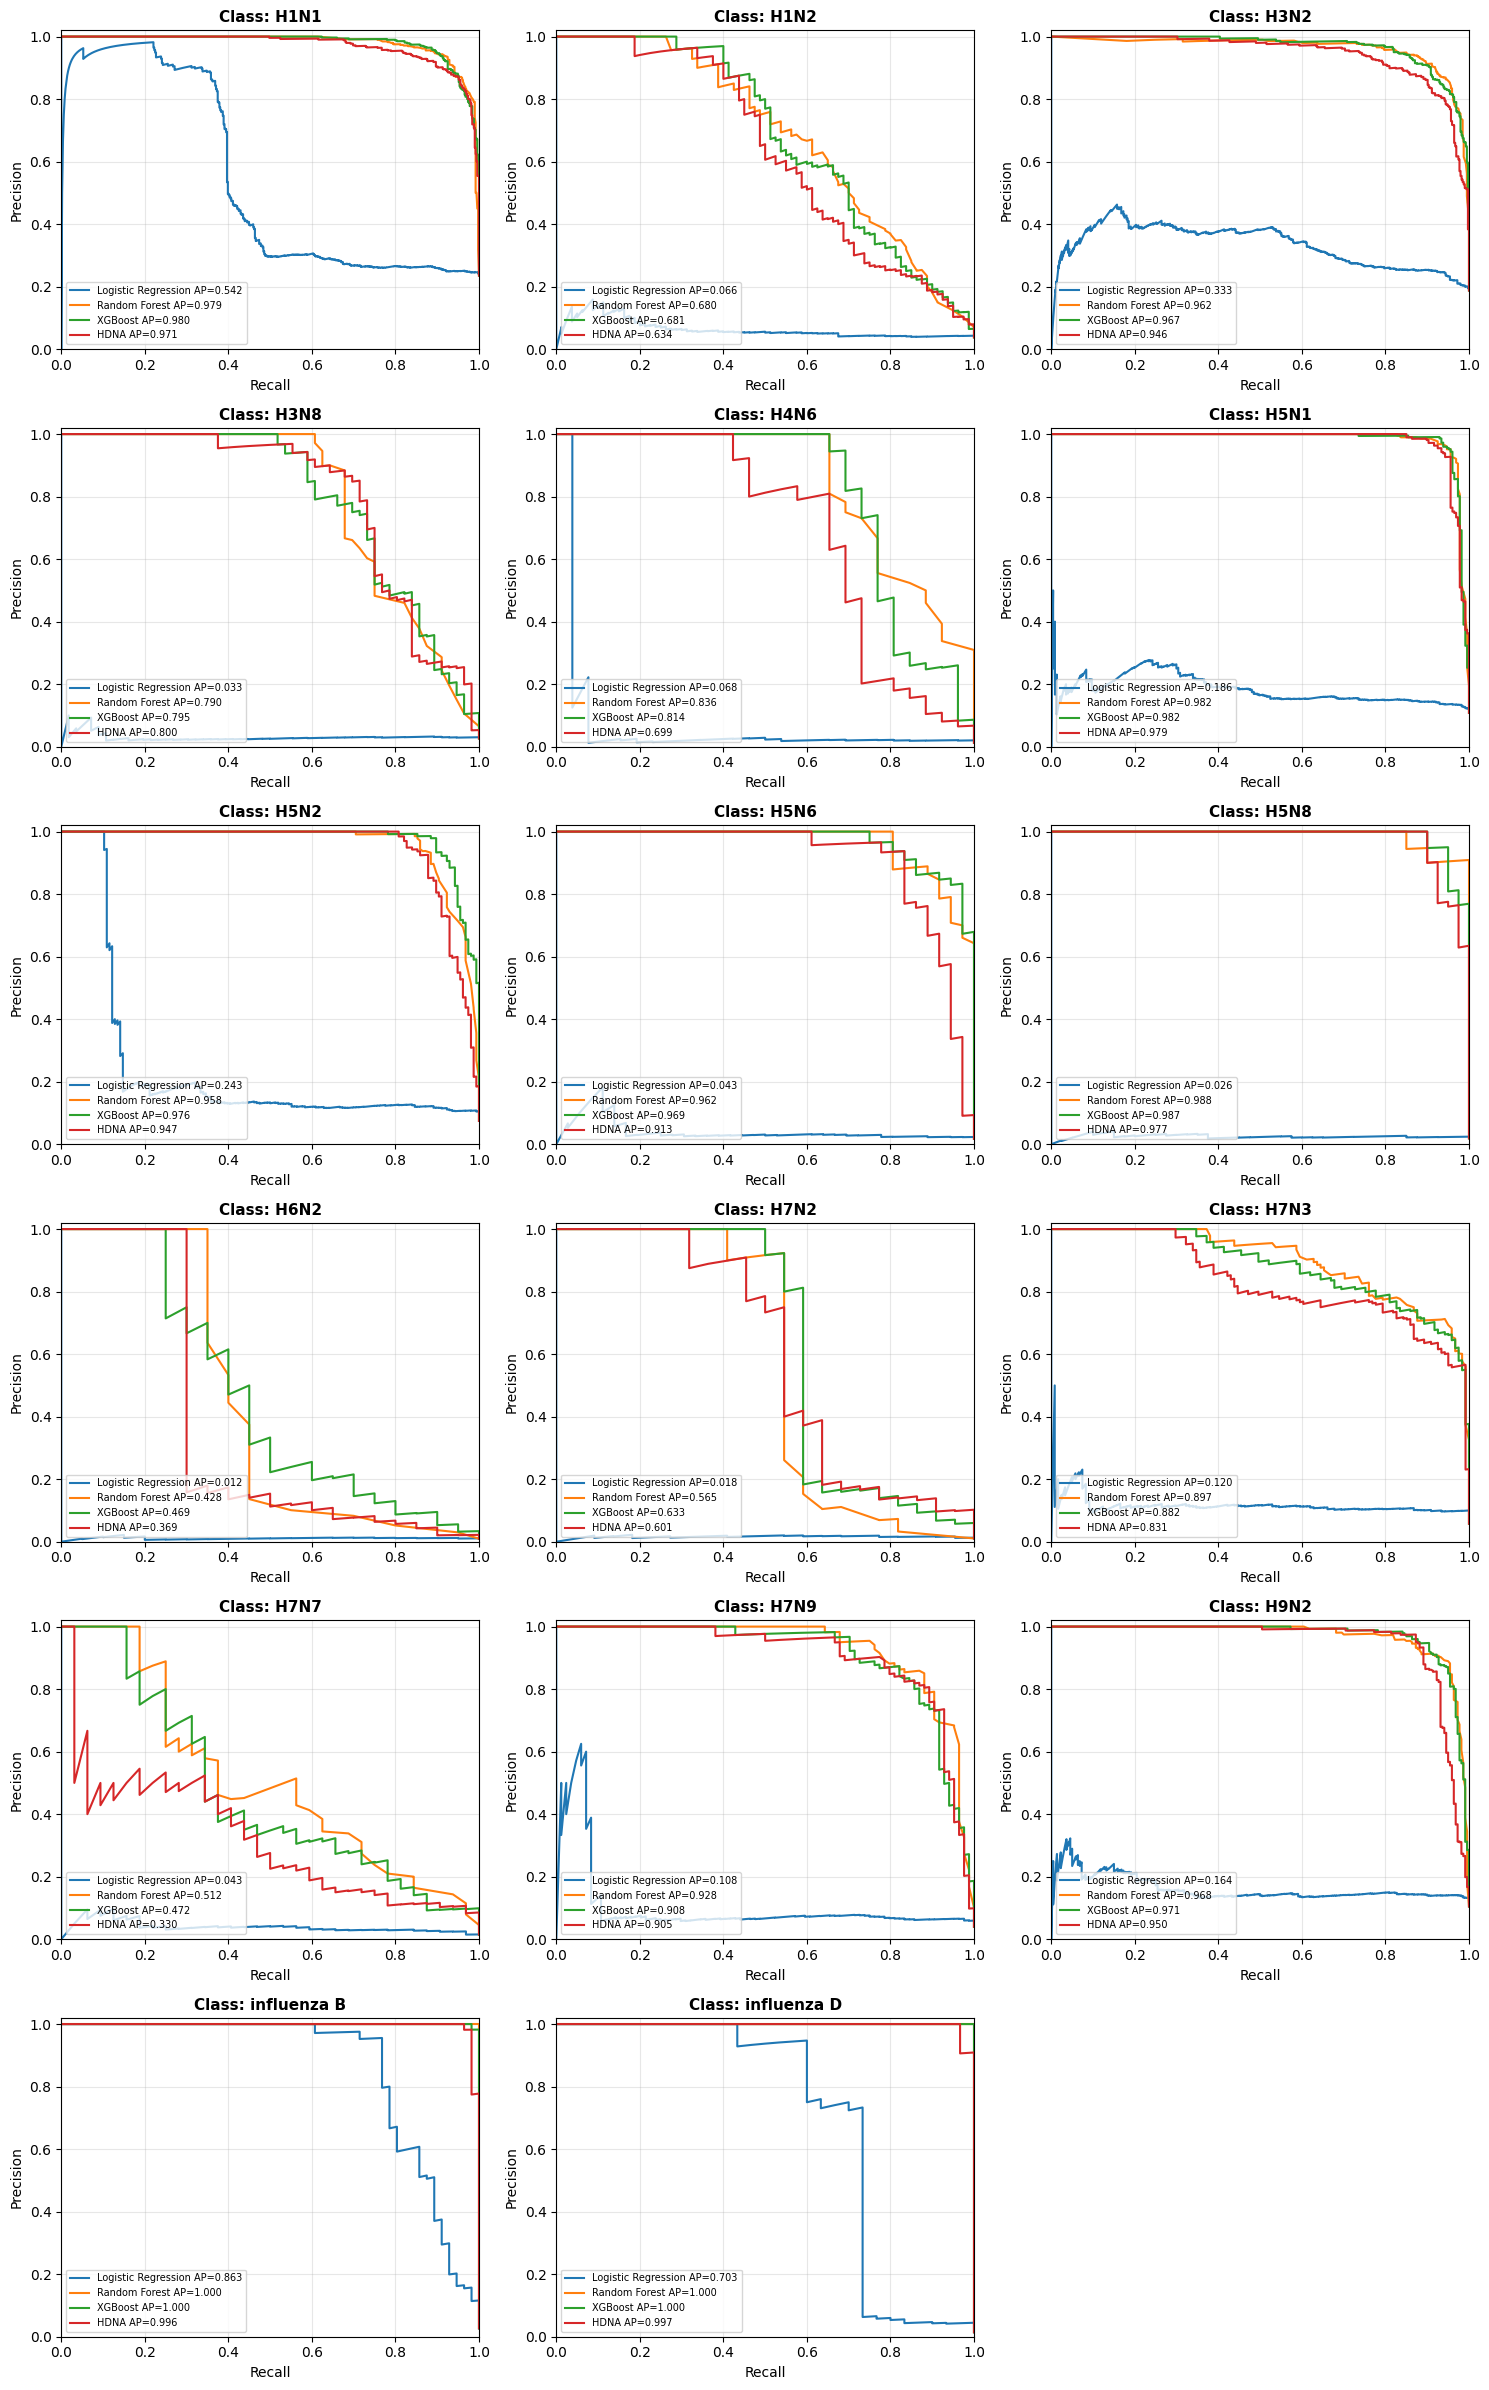

In [13]:
figs, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, cls in enumerate(target_names):
    ax = axes[i]
    for (model_name, res) in models.items():
        precision, recall, _ = res["pr_curves"][cls]
        average_precision = res["avg_precisions"][cls]
        ax.plot(recall, precision, label=f"{model_name} AP={average_precision:.3f}")

    ax.set_title(f"Class: {cls}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=7, loc="lower left")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

axes[n_classes].set_visible(False)

fig.suptitle("PR Curve Comparison - All Models", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/results_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

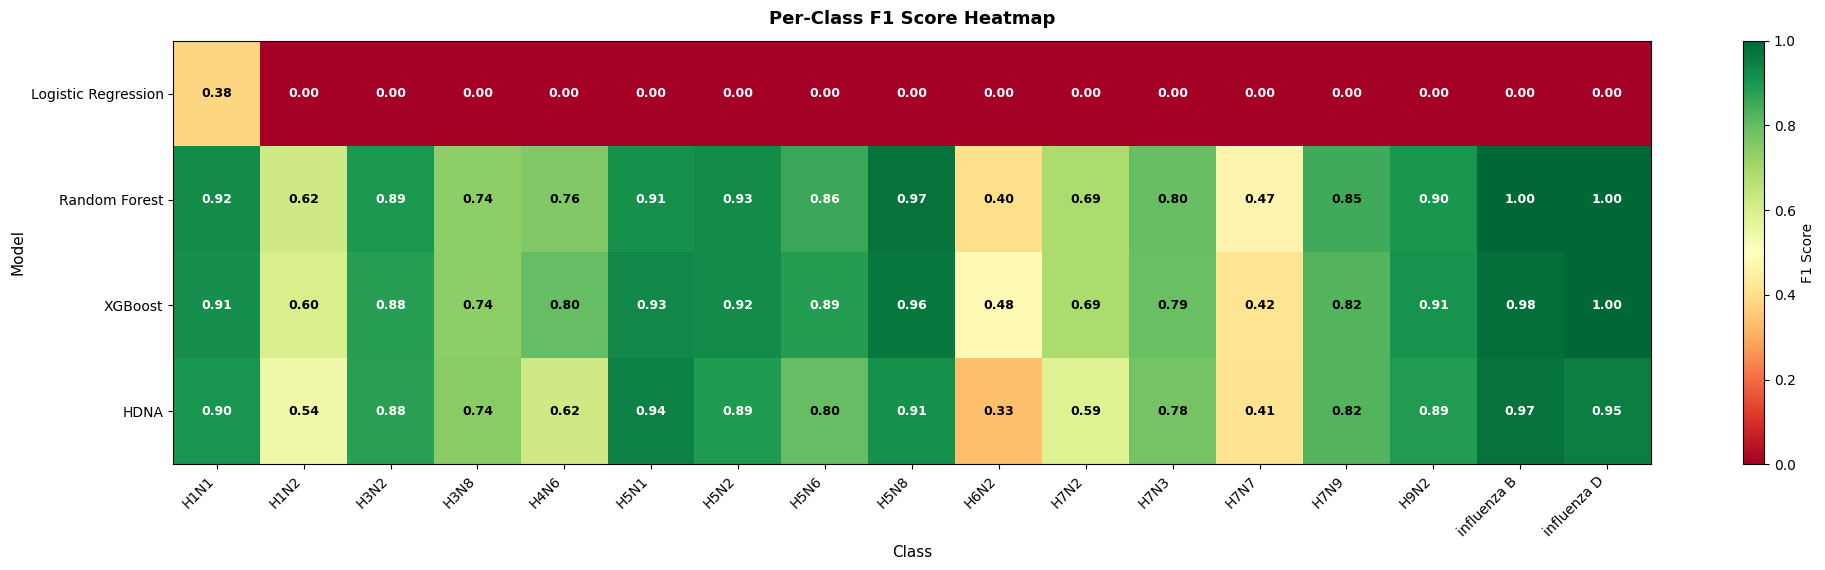

In [23]:
class_names = list(next(iter(models.values()))["per_class_f1"].keys())

f1_matrix = np.array([
    [res["per_class_f1"][cls] for cls in class_names]
    for res in models.values()
])

fig, ax = plt.subplots(figsize=(max(8, len(class_names) * 1.2), len(model_names) * 1.2 + 1))

im = ax.imshow(f1_matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="F1 Score")

# Annotate each cell
for i in range(len(model_names)):
    for j in range(len(class_names)):
        val = f1_matrix[i, j]
        text_color = "black" if 0.3 < val < 0.85 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=9, fontweight="bold", color=text_color)

ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=10)
ax.set_title("Per-Class F1 Score Heatmap", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Model", fontsize=11)

plt.tight_layout()
plt.savefig("../figures/per_class_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

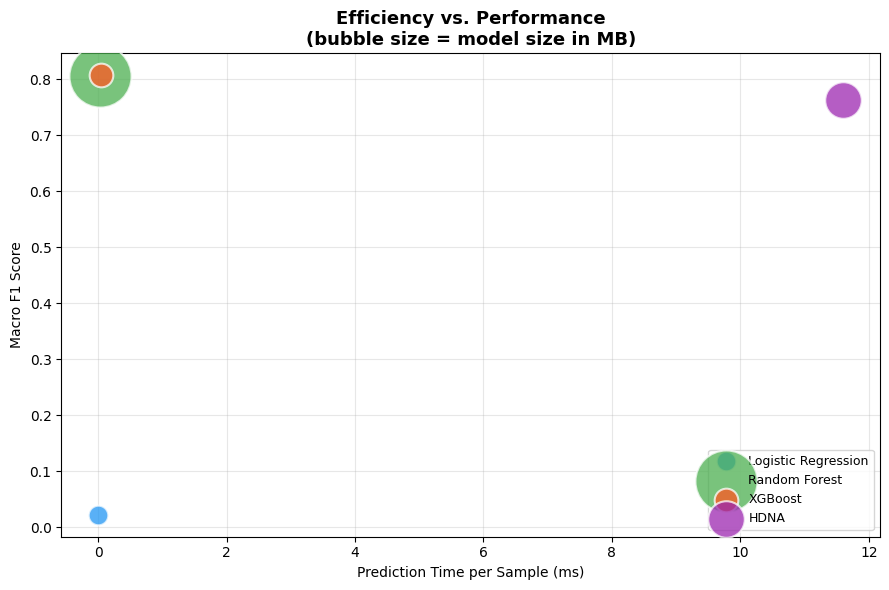

In [28]:
macro_f1   = [res["macro_f1"]                    for res in models.values()]
pred_time  = [res["prediction_time_per_sample_ms"] for res in models.values()]
model_size = [res["model_size_mb"]               for res in models.values()]

# Normalize bubble sizes: smallest model = smallest bubble
min_s, max_s = 200, 2000
size_range = max(model_size) - min(model_size)
if size_range == 0:
    bubble_sizes = [600] * len(model_names)
else:
    bubble_sizes = [
        min_s + (s - min(model_size)) / size_range * (max_s - min_s)
        for s in model_size
    ]

fig, ax = plt.subplots(figsize=(9, 6))

for i, (name, color) in enumerate(zip(model_names, colors)):
    ax.scatter(pred_time[i], macro_f1[i],
               s=bubble_sizes[i], color=color, alpha=0.75,
               edgecolors="white", linewidths=1.5, zorder=3, label=name)



ax.set_xlabel("Prediction Time per Sample (ms)", fontsize=10)
ax.set_ylabel("Macro F1 Score", fontsize=10)
ax.set_title("Efficiency vs. Performance\n(bubble size = model size in MB)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/efficiency_vs_performance.png", dpi=150, bbox_inches="tight")
plt.show()